## Mock Hess diagram and color-magnitude distributions

This code can be used for testing a set of model parameters. 

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from jjmodel.input_ import p, a, inp
from jjmodel.mwdisk import local_run
from helpers import (IMFHandler, SFRHandler, PopHandler, 
    HessConstructor, ParHandler, IFMRHandler, MSAgeHandler, extract_model_tables)  
from prior import prior
from optimizer import prior_tot

In [ ]:
# Specify parameters of the simulation 
# ------------------------------------------------------------

mode_iso = 'Padova'   # isochrone set for all stars except WDs
mode = 'pops_joined'  # type of likelihood, use pops_joined

mag_range = [[-0.5,1.65],[-5,18.5]]  # color-absmag range, do not change
mag_step = [0.02,0.2]                # color-absmag resolution, do not change
mag_smooth = [0.06,0.8]              # color-absmag smoothing in the model, do not change

# Parameters for MS lifetime fits
# Results from MS_Lifetimes.ipynb
age_ms_param_file = 'MS_lifetime_padova_new_metgrid/analysis/'+\
                    'fit_v1_Mbr1.18/tau_ms_params_v1_Mbr1.18.txt' 

# Volume data based on completeness limits
# See Completeness.ipynb and Volume_in_MG.ipynb
d_mg_lim = np.loadtxt('completeness/gdr3_dlim_vs_MG.txt').T
vz_grid = np.loadtxt('completeness/vz_grid_myvolume.txt').T

In [4]:
# Create color-magnitude grid

col_binsc = np.arange(mag_range[0][0]+mag_step[0]/2,mag_range[0][1]+mag_step[0]/2,mag_step[0])
mag_binsc = np.arange(mag_range[1][0]+mag_step[1]/2,mag_range[1][1]+mag_step[1]/2,mag_step[1])

In [7]:
imf_handler = IMFHandler(p)
ifmr_handler = IFMRHandler(a)
sfr_handler = SFRHandler(p, a, inp)
pop_handler = PopHandler(p, a, inp)
constructor = HessConstructor(p, a, mag_range, mag_step)
msage_handler = MSAgeHandler(param_file=age_ms_param_file)

# Define reference SFR and IMF (default parameters from SJ21)
SFR_ref = sfr_handler.create_reference_sfr()
imf_ref, (mass_binsc, IMF_ref) = imf_handler.create_reference_imf()

# Create stellar assemblies (reference) tables 
# (predictions for the reference SFR, IMF, Cummings+18 IFMR, 
# and DA fraction 0.8 without Teff dependence)
pop_tabs_ref = pop_handler.create_reference_pop_tabs(imf_ref,mode_iso,FeH_scatter=0.07,Nmet_dt=7,wd='ms+wd')
pop_tabs_ref = pop_handler.create_reference_columns(pop_tabs_ref,['N', 'Mini', 'age', 'age_WD'])

# Prepare position index columns for the reference ages and initial masses
indt, indm = pop_handler.get_age_mass_idx(pop_tabs_ref,mass_binsc)

# Find DA/DB WD position indices
# idx_wd refers to WD, idx_ms - to all other stars
ind_wd = pop_handler.make_wd_idx_dict(pop_tabs_ref) # separated into DA and DB tables
idx_wd, idx_ms = pop_handler.separate_wd_ms_idx(pop_tabs_ref,ind_wd) # here WD are all together

# Find position indices of CMD-defined populations:
# white dwarfs, giants, main sequence (MS), upper MS, and lower MS
idx_pop = pop_handler.split_into_pops(pop_tabs_ref)
idx_pop_combined = pop_handler.combine_pops_indices(pop_tabs_ref,idx_pop)

# Calculate vz_mag grid - for each row in pop_tabs_ref it gives volume accupied 
# by these type of stars at each z (corresponds to the modeled vertical grid)
vz_mag = pop_handler.get_vz_mag(pop_tabs_ref, d_mg_lim, vz_grid)


Stellar population synthesis for R = 8.275 kpc:
Warning. Some of modeled metallicities (halo) are outside of Padova metallicity range [-2.2,0.5], i.e., the adopted best isochrones may be not representative.
	thin disk	thick disk	halo


In [11]:
# Choose parameters that you want to test
# ------------------------------------------
par_optim = {
    'ifmr':         ['alpha1','alpha2','alpha3'], 
    'dcool':        ['alpha_cool'],
    'f_dadb':       ['f_da'],
    'sfr': {'d':    ['dzeta','eta','sigmad','sigmap0','tpk0']},
    'imf':          ['a0', 'a1', 'a2']
}

par_handler = ParHandler(par_optim,prior)
labels = par_handler.get_flat_param_list()
params_mean, params_sigma = par_handler.get_prior_for_params()

# And specify their values 

# Use this line for te default model
params = params_mean

# Or test other combination
# E.g. if you want to test predictions for the best parameters of MCMC run 
# (output of MCMC_Plot.ipynb)
params = [0.117,  0.049,  0.102,  0.075,  0.775,  0.751,  5.693, 28.858,
          3.393, 10.602,  0.921,  1.708,  2.852] # mcmc_pop5

In [12]:
param_struct = par_handler.fill_param_struct(params)

# Prepare parameters for posterior calculation
pop_kwargs = par_handler.prepare_posterior_kwargs(
    SFR_ref,
    IMF_ref,
    indt,
    indm,
    mode_pop=mode,
    ind_wd=ind_wd,
    ind_pop=idx_pop_combined,
    ifmr_handler=ifmr_handler,
    msage_handler=msage_handler
)

# Add new SFR and IMF to kwargs if their parameters are varied 
if 'sfr' in param_struct.keys():
    inp, SFR_new = sfr_handler.update_sfr(**param_struct['sfr'])
    pop_kwargs['SFR_new'] = SFR_new

if 'imf' in param_struct.keys():
    _, (_, IMF_new) = imf_handler.update_imf(**param_struct['imf'])
    pop_kwargs['IMF_new'] = IMF_new

# Run the model locally and extract its output tables (potential, scale heights, etc)
out = local_run(p,a,inp,save=False,status_progress=False)
inp_tabs = extract_model_tables(out,inp)

# Update number densities of the stellar assemblies
pop_tabs, indt = pop_handler.update_pop_tabs(param_struct,pop_tabs_ref,**pop_kwargs)

In [13]:
# Generate Hess giagram and its projections 

model = 'pop5' # choose a name suffix to be added to saved txt files

# Total Hess diagram
hess_tot = constructor.generate_hess(
    pop_tabs,indt['d'],inp_tabs,
    mag_range,mag_step,mag_smooth,
    volume='slice',
    vz_mag=vz_mag
    )
np.savetxt(f"output/CMDF/hess_{model}.txt",hess_tot)

# Its projections
proj = constructor.generate_hessproj(
    pop_tabs,
    indt['d'],
    inp_tabs,
    mag_range,
    mag_step,
    mag_smooth,
    vz_mag=vz_mag,
    volume='slice',
    idx_pop=pop_kwargs['ind_pop'],
    ind_lim={'col':100,'mag':-1} # do not change, see this method for details
    )

pops = ['wd','g','ums','ms','lms']
for pop in pops:
    np.savetxt(f'output/CMDF/cdf_{model}_{pop}.txt',
               np.column_stack((proj[pop]['cdf'], proj[pop]['ncdf'])),
               header='cdf ncdf')
    np.savetxt(f'output/CMDF/mdf_{model}_{pop}.txt',
            np.column_stack((proj[pop]['mdf'], proj[pop]['nmdf'])),
            header='mdf nmdf')

Text(0.5, 0, 'M_G')

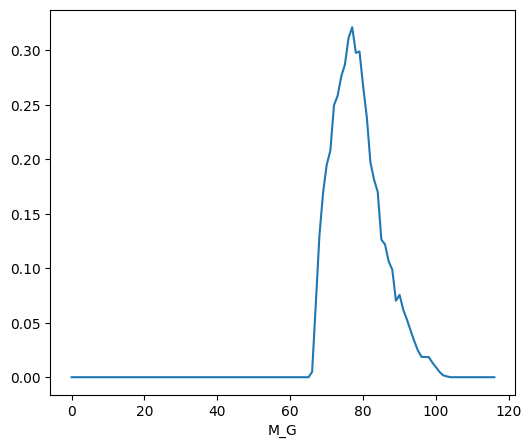

In [14]:
# Test plot

f, ax = plt.subplots(1,1,figsize=(6,5))
ax.plot(proj['lms']['nmdf'])
#ax.set_xlabel('G - G_RP')
ax.set_xlabel('M_G')

/tmp/ipykernel_104336/1620691042.py:43: RuntimeWarning: divide by zero encountered in divide
  diff = np.log10((hess_tot - hess_ref)**2 / (hess_ref + 0.1*hess_ref**2))
/tmp/ipykernel_104336/1620691042.py:43: RuntimeWarning: invalid value encountered in divide
  diff = np.log10((hess_tot - hess_ref)**2 / (hess_ref + 0.1*hess_ref**2))


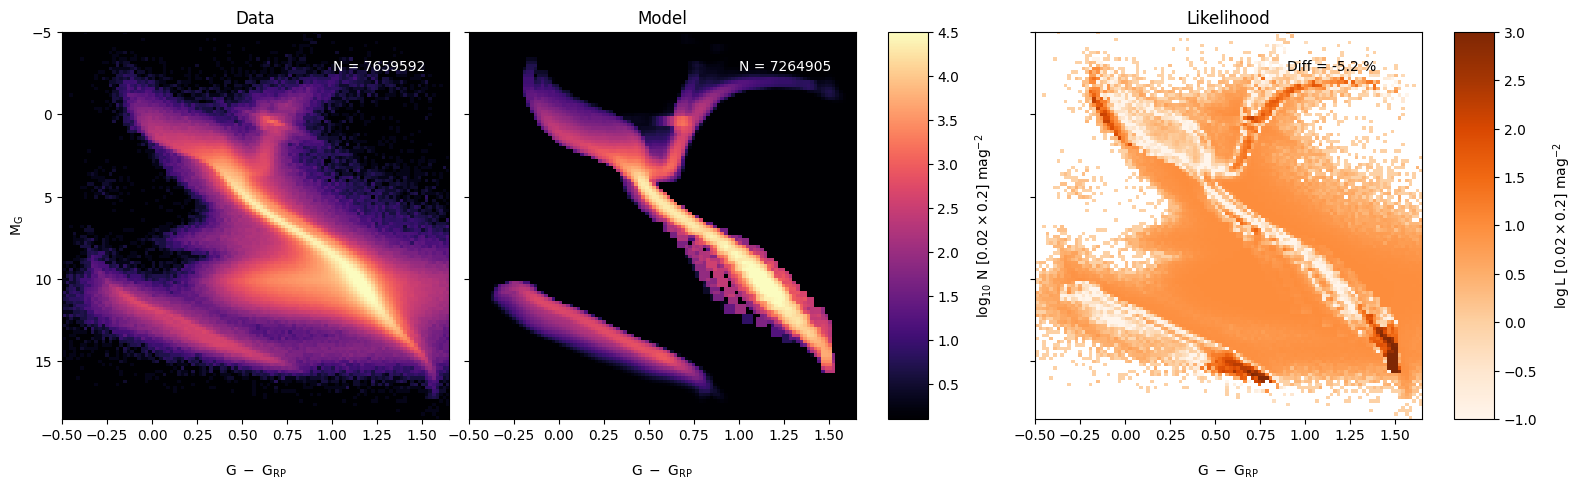

In [16]:
# Compare Hess diagrams
# Check Final_Plots.ipynb for more careful version of this plot 
# (different types of compariosons - ratio, count difference, likelihood)

# Read the data (always compare to the full S0 sample)
hess_ref = np.loadtxt('data/hess/hess_1kpc_s0.txt')

Ntot_d = int(round(sum(sum(hess_ref)),0))
Ntot_m = int(round(sum(sum(hess_tot)),0))

fig, ax = plt.subplots(1,3,figsize=(16,5.5),sharey=True)

# Data
im1 = ax[0].imshow(np.log10(hess_ref+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
ax[0].text(0.7,0.9,'N = '+str(Ntot_d),color='w',transform=ax[0].transAxes)
ax[0].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[0].set_title('Data')
ax[0].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax[0].set_ylabel(r'$\mathrm{M_G}$')

# Model
ax[1].imshow(np.log10(hess_tot+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
ax[1].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[1].text(0.7,0.9,'N = '+str(Ntot_m),color='w',transform=ax[1].transAxes)
#ax[1].set_title('Model (' + mode_iso + ')')['d']
ax[1].set_title('Model')
ax[1].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)


fig.subplots_adjust(left=0.05,wspace=0.05,right=0.8,top=0.93)
pos = ax[1].get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im1,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)

# Difference
diff = np.log10((hess_tot - hess_ref)**2 / (hess_ref + 0.1*hess_ref**2))

pos_x2 = ax[2].get_position()
ax[2].set_position([pos_x2.x0+0.1,pos_x2.y0,pos_x2.width,pos_x2.height])

im2 = ax[2].imshow(diff,interpolation=None,cmap=mpl.colormaps['Oranges'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=-1.0,vmax=3.0)
ax[2].text(0.65,0.9,'Diff = '+str(np.round(100*(Ntot_m-Ntot_d)/Ntot_d,1))+' %',
           color='k',transform=ax[2].transAxes)
ax[2].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[2].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15)
ax[2].set_title('Likelihood')

pos2_new = ax[2].get_position()
cax = fig.add_axes([pos2_new.x0+pos2_new.width+0.02,pos2_new.y0,0.025,pos2_new.height])
cbar = fig.colorbar(im2,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{\log{L} \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10)

#plt.savefig("output/CMDF/hess_m2d_"+model+'.png')


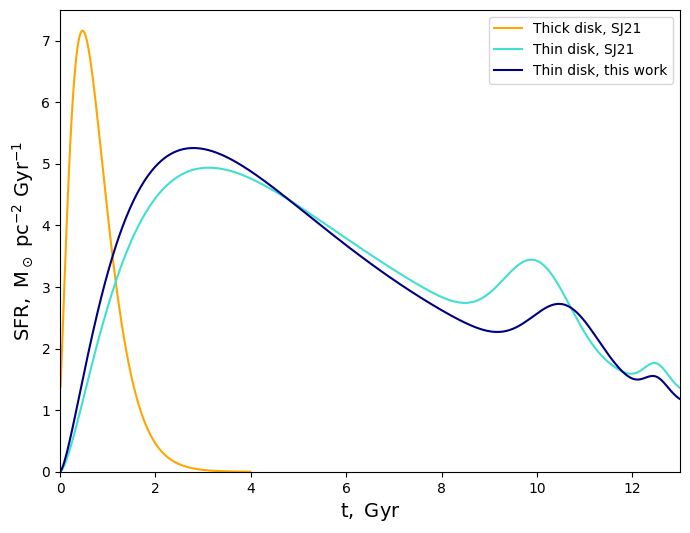

In [17]:
# Check the default vs new SFR 

_, SFR_new = sfr_handler.update_sfr(**param_struct['sfr'])


f, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(a.t[:a.jt],SFR_ref['t'],c='orange',label='Thick disk, SJ21')
ax.plot(a.t,SFR_ref['d'], c='turquoise', label='Thin disk, SJ21')
ax.plot(a.t,SFR_new['d'], c='navy', label='Thin disk, this work')
ax.set_xlabel(r'$\mathrm{t, \ Gyr}$',fontsize=14)
ax.set_ylabel(r'$\mathrm{SFR, \ M_\odot \ pc^{-2} \ Gyr^{-1}}$',fontsize=14)
ax.set_xlim(0,13)
ax.set_ylim(0,7.5)
ax.legend(loc=1)
#f.savefig('./output/final_plots/sfr_comparison_pop5.png')